# Question 2

Classification (Hard)
1. Build a logistic regression model to classify handwritten digits from the MNIST
dataset.
2. Evaluate the model performance using accuracy, precision, recall, and F1 score.
3. Fine-tune the model hyperparameters using grid search CV to improve
performance.
4. Visualize the decision boundary of the model.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0


In [ ]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='auto'
)

log_reg.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto')

In [ ]:
y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Accuracy : 0.9259
Precision: 0.9248943191389738
Recall   : 0.9247910790540971
F1 Score : 0.9247747742435932


In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10]}, scoring='accuracy')

In [ ]:
best_model = grid.best_estimator_
print("Best C:", grid.best_params_)


Best C: {'C': 0.1}


In [ ]:
y_pred_best = best_model.predict(X_test)
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))


Tuned Accuracy: 0.9258


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_pca, y_train)


LogisticRegression(max_iter=1000)

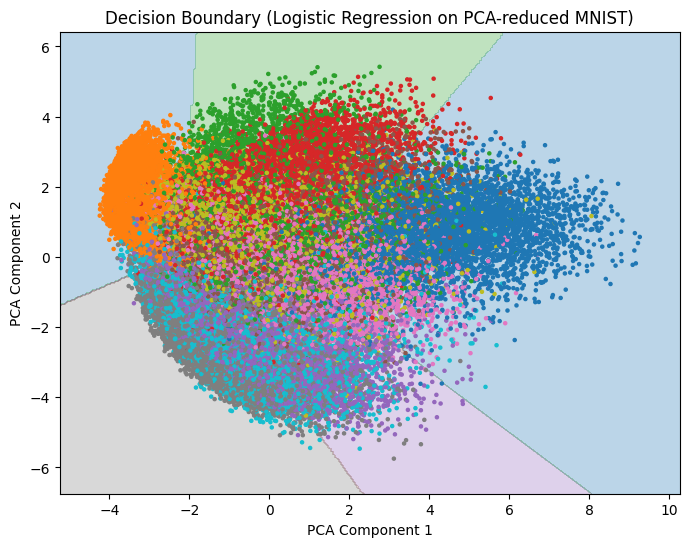

In [ ]:
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab10')
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, s=5, cmap='tab10')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Decision Boundary (Logistic Regression on PCA-reduced MNIST)")
plt.show()
